In [2]:
#!git pull

In [3]:
#!pip install xgboost

In [4]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, precision_score, recall_score)

In [5]:
df = pd.read_csv('../data/cleaned_data.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
print(df.shape) 
df.info() 

(2200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [7]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [8]:
print("Number of crops:", df["label"].nunique())
print("\nAll crops:")
print(df["label"].value_counts())

Number of crops: 22

All crops:
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64


In [9]:
X = df.drop("label", axis=1)
y = df["label"]

# XGBoost needs numbers, so encode the crop names
le = LabelEncoder()  #the tool converting numbers to words
y_encoded = le.fit_transform(y)   #assigns each crop a number and implements it 

print("Crops found:", le.classes_)
print("Number of crops:", len(le.classes_))

Crops found: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']
Number of crops: 22


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1760
Testing samples: 440


In [11]:
#Training thje XGboost
model = XGBClassifier(
    n_estimators=100, #100 trees, each learning from the previous' mistake
    learning_rate=0.1, #how fast the model runs
    max_depth=6,  #deeper means more complex pattern and risk of overfitting
    eval_metric="mlogloss",  #metric that calculates how acurately the predicted prob match the actual class labels
    random_state=42 #makes results reproducible
)

model.fit(X_train, y_train) #the actual learning
print("Model trained successfully!")

Model trained successfully!


In [12]:
#classification report function
def classification_metrics(y_actual, y_pred):
    acc = round(accuracy_score(y_actual, y_pred)*100, 2)  #how correct the model is
    precision = round(precision_score(y_actual, y_pred, average="weighted")*100, 2) #reputability
    recall = round(recall_score(y_actual, y_pred, average="weighted")*100, 2) #how well it finds the actual positives
    cm = confusion_matrix(y_actual, y_pred)
    return acc, precision, recall, cm

In [13]:
#evaluate the model
y_pred = model.predict(X_test) #predictions using the test data

acc, precision, recall, cm = classification_metrics(y_test, y_pred)

# Print results in percentage
print(f"Accuracy:  {acc}%")
print(f"Precision: {precision}%")
print(f"Recall:    {recall}%")

Accuracy:  98.64%
Precision: 98.69%
Recall:    98.64%


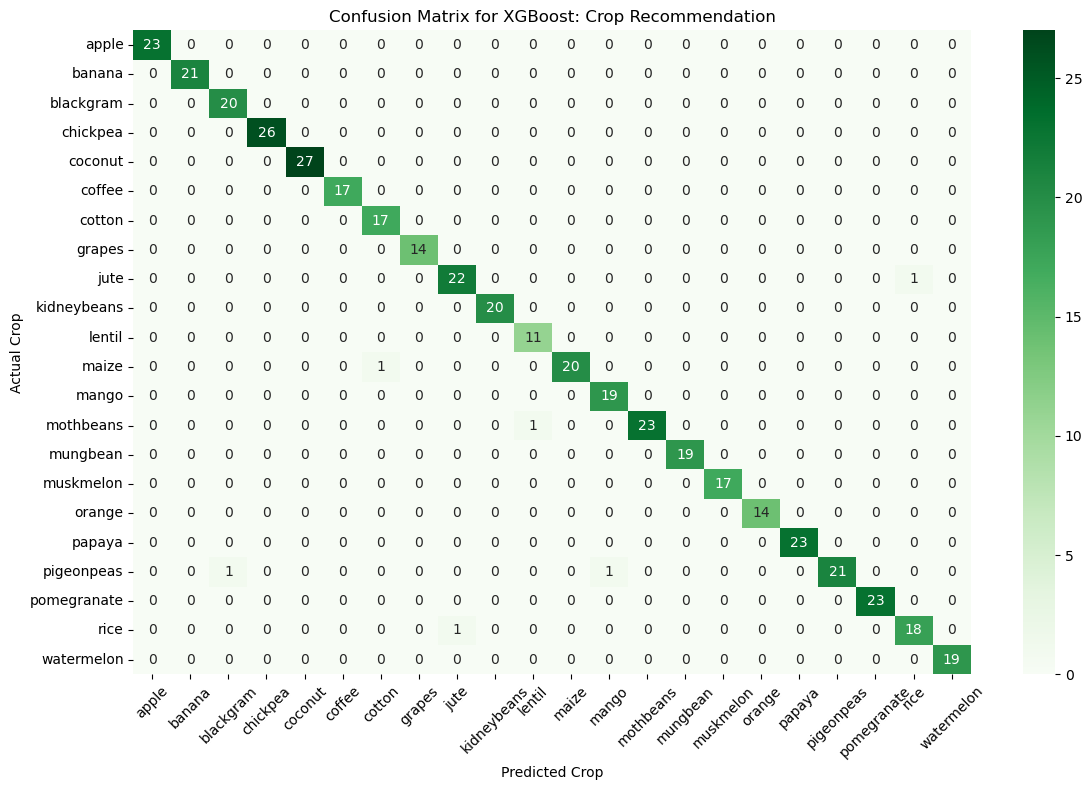

In [17]:
#confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",  #annot is to show the numbers inside the cell and fmt is formatting to decimal
            xticklabels=le.classes_, #label with crop names instead of numbers
            yticklabels=le.classes_)
plt.title("Confusion Matrix for XGBoost: Crop Recommendation System")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=45) #prevents overlapping of the crops
plt.tight_layout()
plt.show()

In [15]:
#!git add .
#!git commit -m "a commit"
#!git push

[main da7e47d] a commit
 2 files changed, 167 insertions(+), 245 deletions(-)


To https://github.com/TINOZOERAMONA/croprecommendationproject.git
   bc03d1d..da7e47d  main -> main
